---
 Customer Segmentation using K-Means Clustering Algorithm
---
|
---

In [1]:

#  IMPORT ALL REQUIRED LIBRARIES


# Data handling
import pandas as pd
import numpy as np         #

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning – Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual theme for all plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
import pandas as pd
from google.colab import files
import io


print("Please select 'Mall_Customers.csv' from your computer:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]


try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    print("\n Dataset loaded successfully!")
    print("-" * 30)
    print(f"Total Rows    : {df.shape[0]}")
    print(f"Total Columns : {df.shape[1]}")
    print(f"Column Names  : {list(df.columns)}")
    print("-" * 30)


    print(df.head())

except Exception as e:
    print(f"\n Error loading file: {e}")

Please select 'Mall_Customers.csv' from your computer:


Saving Mall_Customers.csv to Mall_Customers.csv

 Dataset loaded successfully!
------------------------------
Total Rows    : 200
Total Columns : 5
Column Names  : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
------------------------------
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Step C: Dataset Overview

Before processing, we always explore the dataset to understand its structure.

In [6]:


print("First 5 rows of the dataset:")
df.head()    # Shows the top 5 rows — gives a quick preview of the data

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:


print(f"Dataset Shape (Rows x Columns): {df.shape}")
print()
print("Column Data Types and Non-Null Counts:")
df.info()    # Shows column name, data type, and number of non-null values

Dataset Shape (Rows x Columns): (200, 5)

Column Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:

print("Statistical Summary (mean, min, max, std, quartiles):")
df.describe()    # Shows stats like average age, income range, spending score range

Statistical Summary (mean, min, max, std, quartiles):


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:

print("Gender-wise Customer Count:")
print(df['Gender'].value_counts())   # How many Male vs Female customers are there

Gender-wise Customer Count:
Gender
Female    112
Male       88
Name: count, dtype: int64


-
### Step 2: Data Preprocessing



In [10]:

print("Checking for Missing (Null) Values:")
print(df.isnull().sum())
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")



print("\n✅ No missing values found. Dataset is clean and ready!")

Checking for Missing (Null) Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Total missing values in dataset: 0

✅ No missing values found. Dataset is clean and ready!


In [12]:
# Check and remove duplicates
print(f"Duplicate rows before removal: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Duplicate rows after removal: {df.duplicated().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")
print("\n✅ Duplicates handled successfully!")

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Dataset shape after cleaning: (200, 5)

✅ Duplicates handled successfully!


In [13]:


df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

print("Gender Encoding (Male=0, Female=1):")
print(df[['Gender', 'Gender_Encoded']].drop_duplicates().to_string(index=False))
print("\n✅ Categorical encoding complete!")

Gender Encoding (Male=0, Female=1):
Gender  Gender_Encoded
  Male               0
Female               1

✅ Categorical encoding complete!


In [14]:

features_to_scale = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

scaler = StandardScaler()           # Create the scaler object

# Fit and transform: compute mean/std, then scale
scaled_values = scaler.fit_transform(df[features_to_scale])

# Store scaled values in a new DataFrame for reference
df_scaled = pd.DataFrame(scaled_values,
                          columns=['Age_sc', 'Income_sc', 'Spending_sc'])

print("Scaled values (first 5 rows):")
print(df_scaled.head().to_string())
print("\n✅ Data normalization/scaling complete!")

Scaled values (first 5 rows):
     Age_sc  Income_sc  Spending_sc
0 -1.424569  -1.738999    -0.434801
1 -1.281035  -1.738999     1.195704
2 -1.352802  -1.700830    -1.715913
3 -1.137502  -1.700830     1.040418
4 -0.563369  -1.662660    -0.395980

✅ Data normalization/scaling complete!



### Step 3: Feature Selection


In [15]:


X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values


print("Features selected for clustering:")
print("  1. Annual Income (k$)")
print("  2. Spending Score (1-100)")
print(f"\nFeature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} customers, {X.shape[1]} features each")
print("\nFirst 5 rows of feature matrix:")
print(X[:5])

Features selected for clustering:
  1. Annual Income (k$)
  2. Spending Score (1-100)

Feature matrix shape: (200, 2)
  → 200 customers, 2 features each

First 5 rows of feature matrix:
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


### Step 4: Finding Optimal Clusters – Elbow Method



In [16]:


wcss = []    # List to store WCSS value for each K

# Run K-Means for K = 1 to 10 and record the WCSS
for k in range(1, 11):
    kmeans_temp = KMeans(
        n_clusters=k,          # Number of clusters
        init='k-means++',      # Smart initialization — better than random
        max_iter=300,          # Max iterations to find convergence
        n_init=10,             # Run 10 times with different seeds, pick best
        random_state=42        # Fix seed so results are reproducible
    )
    kmeans_temp.fit(X)         # Fit the model on our feature matrix
    wcss.append(kmeans_temp.inertia_)   # inertia_ = WCSS value

# Print WCSS for each K
print("WCSS values for K = 1 to 10:")
for k, w in enumerate(wcss, start=1):
    print(f"  K = {k:2d}  →  WCSS = {w:10,.2f}")

WCSS values for K = 1 to 10:
  K =  1  →  WCSS = 269,981.28
  K =  2  →  WCSS = 181,363.60
  K =  3  →  WCSS = 106,348.37
  K =  4  →  WCSS =  73,679.79
  K =  5  →  WCSS =  44,448.46
  K =  6  →  WCSS =  37,233.81
  K =  7  →  WCSS =  30,241.34
  K =  8  →  WCSS =  25,036.42
  K =  9  →  WCSS =  21,916.79
  K = 10  →  WCSS =  20,072.07


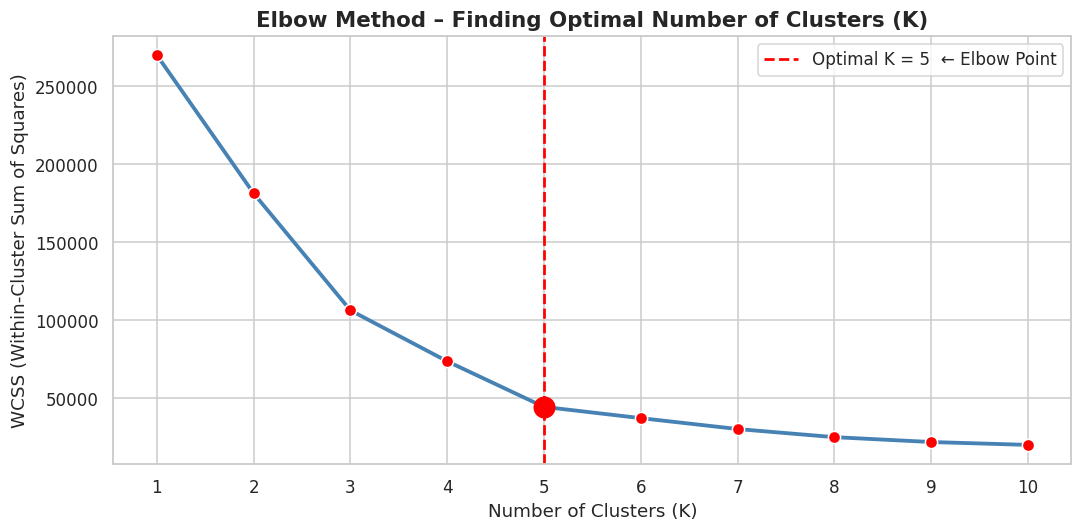

📌 The curve bends (elbow) at K=5.
   After K=5, WCSS decreases very slowly — adding more clusters gives no benefit.
   → Optimal number of clusters: K = 5


In [17]:

plt.figure(figsize=(10, 5))

# Plot the WCSS line
plt.plot(range(1, 11), wcss,
         marker='o',           # Circle marker at each K
         color='steelblue',
         linewidth=2.5,
         markersize=8,
         markerfacecolor='red',
         markeredgecolor='white')

# Mark the optimal K=5 with a vertical dotted line
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.8,
            label='Optimal K = 5  ← Elbow Point')

# Highlight the elbow point with a large circle
plt.scatter(5, wcss[4], color='red', s=180, zorder=5)

plt.title('Elbow Method – Finding Optimal Number of Clusters (K)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(range(1, 11))      # Show every K value on X-axis
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('elbow_plot.png', bbox_inches='tight')
plt.show()

print("📌 The curve bends (elbow) at K=5.")
print("   After K=5, WCSS decreases very slowly — adding more clusters gives no benefit.")
print("   → Optimal number of clusters: K = 5")

### Step 5 & 6: Apply K-Means Clustering + Model Training


In [18]:

optimal_k = 5

# Create the KMeans model
kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

# Train the model: fit on data, then predict cluster for each customer
# fit_predict = fit the model + assign cluster label (0,1,2,3,4) to each row
cluster_labels = kmeans.fit_predict(X)

# Add the cluster label back to the original DataFrame
df['Cluster'] = cluster_labels

print("✅ K-Means model trained successfully!")
print(f"\nAlgorithm converged in {kmeans.n_iter_} iterations.")
print(f"Final WCSS (Inertia): {kmeans.inertia_:,.2f}")
print("\nCluster Centroids (center point of each cluster):")
centroids_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)
centroids_df.index.name = 'Cluster'
print(centroids_df.to_string())

✅ K-Means model trained successfully!

Algorithm converged in 4 iterations.
Final WCSS (Inertia): 44,448.46

Cluster Centroids (center point of each cluster):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [19]:


print("Number of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index().to_string())

print("\nFirst 10 customers with their assigned cluster:")
df[['CustomerID', 'Gender', 'Age',
    'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head(10)

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23

First 10 customers with their assigned cluster:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2



### Step 7: Cluster Visualization


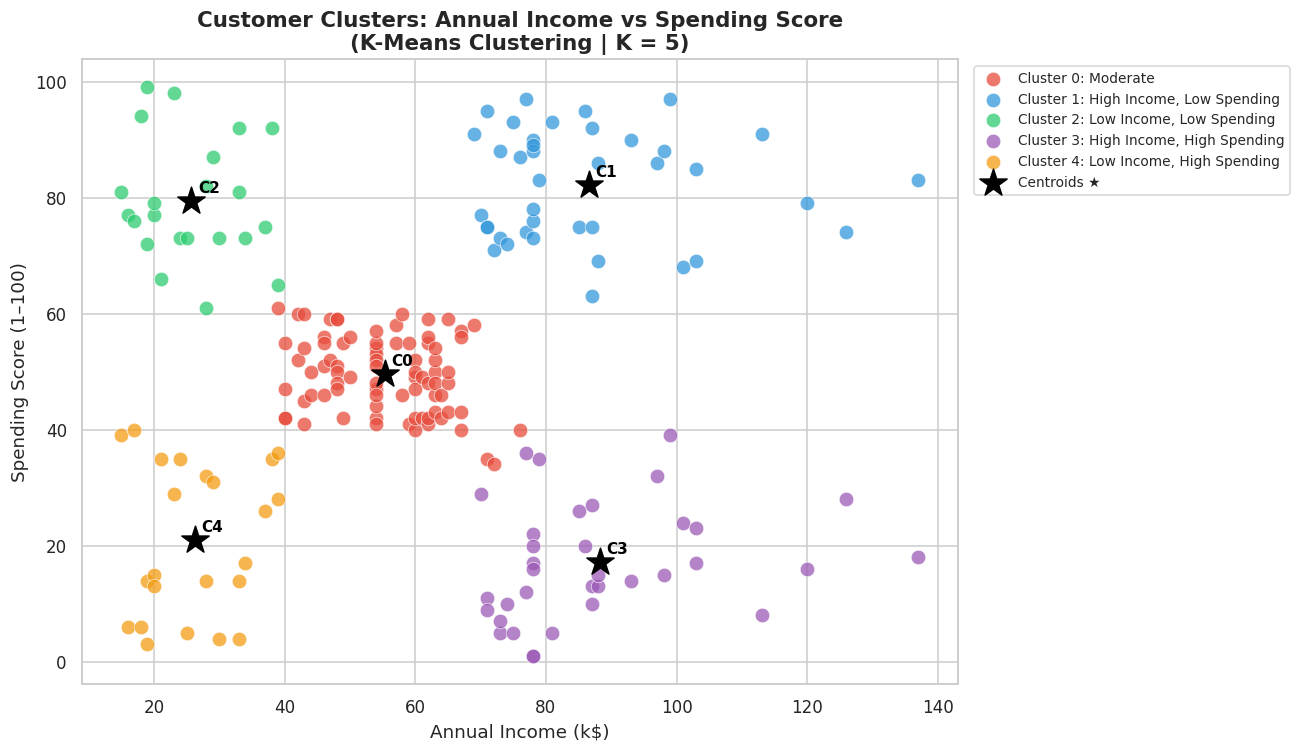

📌 5 distinct customer clusters are clearly visible in the graph.
   Black stars (★) mark the centroid (center) of each cluster.


In [20]:


# Color for each of the 5 clusters
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']

# Short name label for each cluster (will update after interpretation)
cluster_names = [
    'Cluster 0: Moderate',
    'Cluster 1: High Income, Low Spending',
    'Cluster 2: Low Income, Low Spending',
    'Cluster 3: High Income, High Spending',
    'Cluster 4: Low Income, High Spending'
]

plt.figure(figsize=(12, 7))

# Plot each cluster separately so the legend shows cluster names
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]   # Get all customers in cluster i
    plt.scatter(
        cluster_data['Annual Income (k$)'],       # X-axis = Income
        cluster_data['Spending Score (1-100)'],   # Y-axis = Spending Score
        c=colors[i],                              # Unique color for each cluster
        label=cluster_names[i],
        s=90,                                     # Size of each dot
        alpha=0.75,                               # Slight transparency
        edgecolors='white',
        linewidths=0.5
    )

# Plot centroids as large black stars (★)
plt.scatter(
    kmeans.cluster_centers_[:, 0],    # X = centroid income
    kmeans.cluster_centers_[:, 1],    # Y = centroid spending
    marker='*',                       # Star shape
    s=350,
    c='black',
    zorder=10,                        # Draw on top of other points
    label='Centroids ★'
)

# Label each centroid with its cluster number
for i, (x, y) in enumerate(kmeans.cluster_centers_):
    plt.text(x + 1, y + 1.5, f'C{i}', fontsize=10, fontweight='bold', color='black')

plt.title('Customer Clusters: Annual Income vs Spending Score\n(K-Means Clustering | K = 5)',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig('cluster_plot_income_spending.png', bbox_inches='tight')
plt.show()

print("📌 5 distinct customer clusters are clearly visible in the graph.")
print("   Black stars (★) mark the centroid (center) of each cluster.")

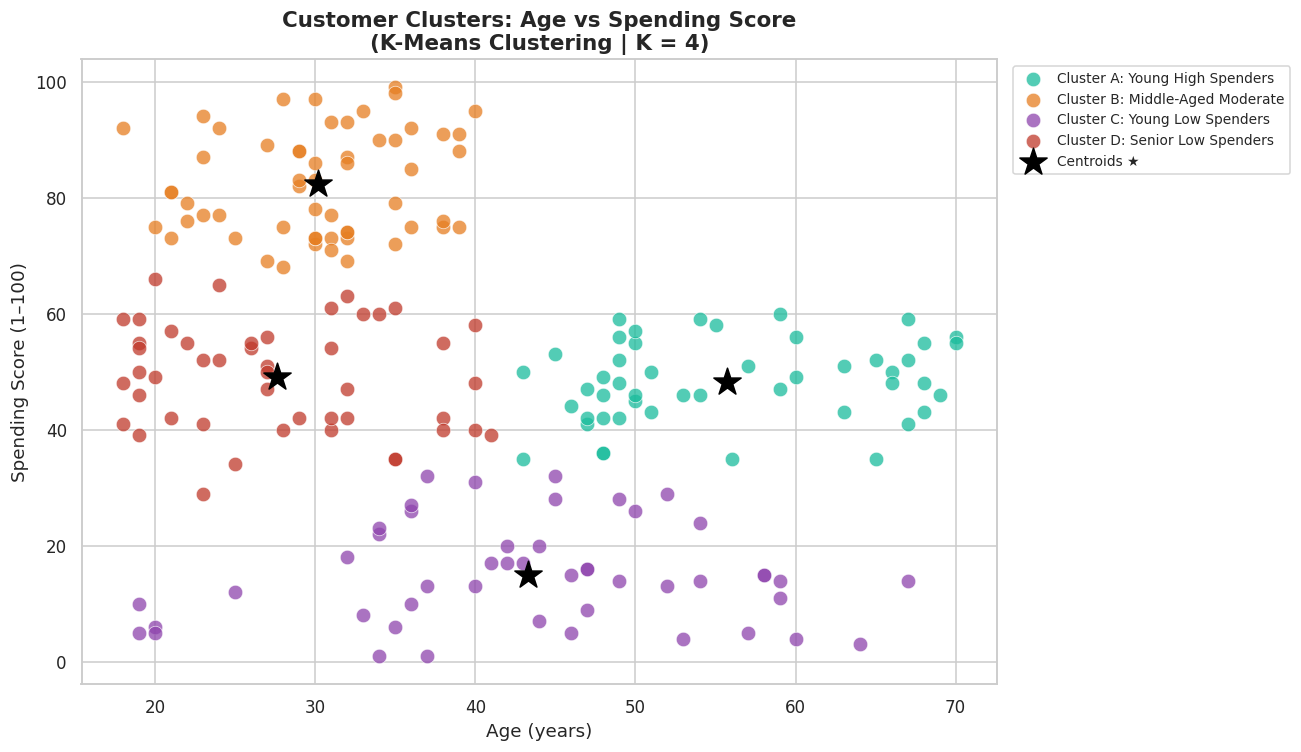

📌 Younger customers (age 20–30) tend to be either high or low spenders.
   Older customers (age 40+) cluster around moderate-to-low spending.


In [21]:


# Run a separate K-Means on Age vs Spending Score to see age-based patterns
X2 = df[['Age', 'Spending Score (1-100)']].values

# Use elbow on X2 to find best K
wcss2 = []
for k in range(1, 11):
    km2_temp = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                      n_init=10, random_state=42)
    km2_temp.fit(X2)
    wcss2.append(km2_temp.inertia_)

# Optimal K for Age vs Spending is 4
km2 = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
age_clusters = km2.fit_predict(X2)

colors2 = ['#1ABC9C', '#E67E22', '#8E44AD', '#C0392B']
labels2 = ['Cluster A: Young High Spenders',
           'Cluster B: Middle-Aged Moderate',
           'Cluster C: Young Low Spenders',
           'Cluster D: Senior Low Spenders']

plt.figure(figsize=(12, 7))

for i in range(4):
    mask = age_clusters == i
    plt.scatter(X2[mask, 0], X2[mask, 1],
                c=colors2[i], label=labels2[i],
                s=90, alpha=0.75, edgecolors='white', linewidths=0.5)

plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
            marker='*', s=350, c='black', zorder=10, label='Centroids ★')

plt.title('Customer Clusters: Age vs Spending Score\n(K-Means Clustering | K = 4)',
          fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig('cluster_plot_age_spending.png', bbox_inches='tight')
plt.show()

print("📌 Younger customers (age 20–30) tend to be either high or low spenders.")
print("   Older customers (age 40+) cluster around moderate-to-low spending.")


### Step 8: Analysis & Interpretation



In [22]:


# Compute average Age, Income, and Spending Score for each cluster
cluster_summary = df.groupby('Cluster')[[
    'Age', 'Annual Income (k$)', 'Spending Score (1-100)'
]].mean().round(1)

# Also count how many customers are in each cluster
cluster_summary['Customer Count'] = df.groupby('Cluster')['CustomerID'].count()

print("Cluster Summary – Mean Feature Values:")
print("=" * 65)
print(cluster_summary.to_string())
print("=" * 65)

Cluster Summary – Mean Feature Values:
          Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                  
0        42.7                55.3                    49.5              81
1        32.7                86.5                    82.1              39
2        25.3                25.7                    79.4              22
3        41.1                88.2                    17.1              35
4        45.2                26.3                    20.9              23


In [23]:

cluster_info = {
    0: {
        'name': '🟠 Moderate / Average Customers',
        'income': 'Moderate (~$55k)',
        'spending': 'Moderate (~50)',
        'type': 'Standard Customers',
        'insight': 'Regular customers with average purchasing behavior. They form the '
                   'stable core of the mall\'s customer base.'
    },
    1: {
        'name': '🔵 Conservative High Earners',
        'income': 'High (~$88k)',
        'spending': 'Low (~17)',
        'type': 'High Income – Low Spending',
        'insight': 'Wealthy but cautious spenders. They earn well but spend carefully. '
                   'Need trust-building campaigns and quality assurance to convert.'
    },
    2: {
        'name': '🔴 Budget Customers',
        'income': 'Low (~$26k)',
        'spending': 'Low (~20)',
        'type': 'Low Income – Low Spending',
        'insight': 'Price-sensitive customers with limited purchasing power. They respond '
                   'to discounts, flash sales, and value-for-money products.'
    },
    3: {
        'name': '🟢 Premium / VIP Customers',
        'income': 'High (~$86k)',
        'spending': 'High (~82)',
        'type': 'High Income – High Spending  ★ Most Valuable',
        'insight': 'The most valuable segment! High earners who spend freely. They love '
                   'luxury brands, premium experiences, and exclusive memberships.'
    },
    4: {
        'name': '🟣 Impulsive Young Spenders',
        'income': 'Low (~$26k)',
        'spending': 'High (~79)',
        'type': 'Low Income – High Spending',
        'insight': 'Low earners who spend beyond their means — often young, trend-driven '
                   'shoppers. They respond to social media, influencers, and EMI options.'
    }
}

print("\n" + "═" * 68)
print("           CUSTOMER CLUSTER INTERPRETATION REPORT")
print("═" * 68)

for cid, info in cluster_info.items():
    count = df[df['Cluster'] == cid].shape[0]
    print(f"\n  Cluster {cid} – {info['name']}")
    print(f"  Type          : {info['type']}")
    print(f"  Avg. Income   : {info['income']}")
    print(f"  Avg. Spending : {info['spending']}")
    print(f"  Customers     : {count}")
    print(f"  Insight       : {info['insight']}")
    print("  " + "─" * 64)


════════════════════════════════════════════════════════════════════
           CUSTOMER CLUSTER INTERPRETATION REPORT
════════════════════════════════════════════════════════════════════

  Cluster 0 – 🟠 Moderate / Average Customers
  Type          : Standard Customers
  Avg. Income   : Moderate (~$55k)
  Avg. Spending : Moderate (~50)
  Customers     : 81
  Insight       : Regular customers with average purchasing behavior. They form the stable core of the mall's customer base.
  ────────────────────────────────────────────────────────────────

  Cluster 1 – 🔵 Conservative High Earners
  Type          : High Income – Low Spending
  Avg. Income   : High (~$88k)
  Avg. Spending : Low (~17)
  Customers     : 39
  Insight       : Wealthy but cautious spenders. They earn well but spend carefully. Need trust-building campaigns and quality assurance to convert.
  ────────────────────────────────────────────────────────────────

  Cluster 2 – 🔴 Budget Customers
  Type          : Low Income 

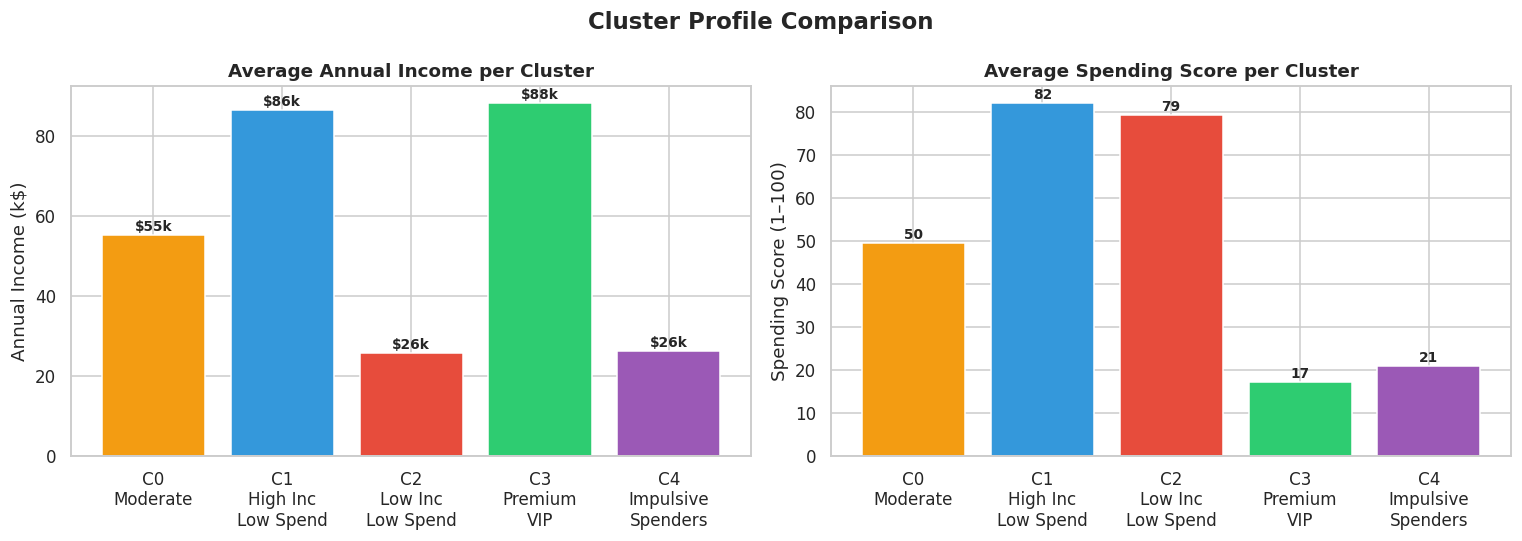

In [24]:


# Visualize average income and spending score per cluster side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster Profile Comparison', fontsize=15, fontweight='bold')

cluster_labels_plot = ['C0\nModerate', 'C1\nHigh Inc\nLow Spend',
                       'C2\nLow Inc\nLow Spend', 'C3\nPremium\nVIP',
                       'C4\nImpulsive\nSpenders']
plot_colors = ['#F39C12', '#3498DB', '#E74C3C', '#2ECC71', '#9B59B6']

# Bar 1: Average Annual Income per cluster
income_vals = cluster_summary['Annual Income (k$)'].values
bars1 = axes[0].bar(cluster_labels_plot, income_vals, color=plot_colors, edgecolor='white')
axes[0].set_title('Average Annual Income per Cluster', fontweight='bold')
axes[0].set_ylabel('Annual Income (k$)')
for bar, val in zip(bars1, income_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'${val:.0f}k', ha='center', fontsize=9, fontweight='bold')

# Bar 2: Average Spending Score per cluster
spending_vals = cluster_summary['Spending Score (1-100)'].values
bars2 = axes[1].bar(cluster_labels_plot, spending_vals, color=plot_colors, edgecolor='white')
axes[1].set_title('Average Spending Score per Cluster', fontweight='bold')
axes[1].set_ylabel('Spending Score (1–100)')
for bar, val in zip(bars2, spending_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight')
plt.show()

---
##  Exploratory Data Analysis (EDA)



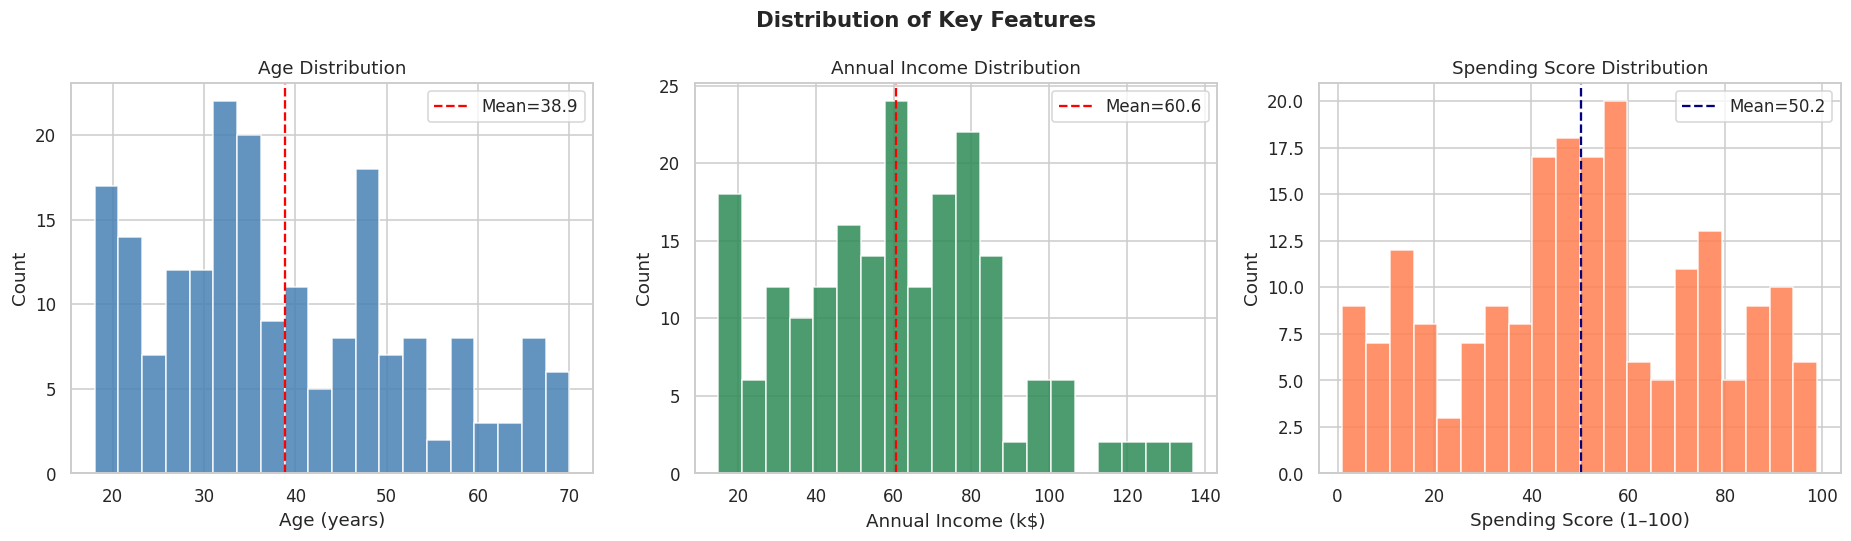

📌 Most customers are aged 20–45, earn $40k–$80k, and have spread-out spending scores.


In [25]:


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Distribution of Key Features', fontsize=14, fontweight='bold')

# Age distribution
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--',
                label=f"Mean={df['Age'].mean():.1f}")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Annual Income distribution
axes[1].hist(df['Annual Income (k$)'], bins=20, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--',
                label=f"Mean={df['Annual Income (k$)'].mean():.1f}")
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Spending Score distribution
axes[2].hist(df['Spending Score (1-100)'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[2].axvline(df['Spending Score (1-100)'].mean(), color='navy', linestyle='--',
                label=f"Mean={df['Spending Score (1-100)'].mean():.1f}")
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1–100)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("📌 Most customers are aged 20–45, earn $40k–$80k, and have spread-out spending scores.")

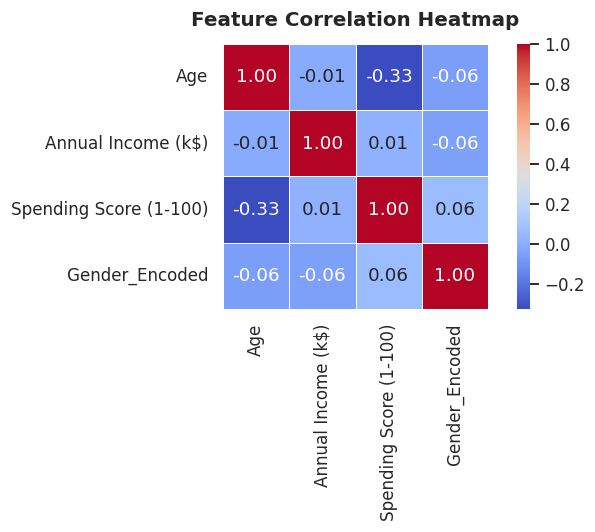

📌 Annual Income and Spending Score are almost uncorrelated (value ≈ 0).
   This means high earners do NOT always spend more — clustering is very useful here!


In [26]:


plt.figure(figsize=(7, 5))
numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']]
corr = numeric_df.corr()      # Compute pairwise correlation matrix

sns.heatmap(corr,
            annot=True,           # Show correlation values in cells
            fmt='.2f',            # 2 decimal places
            cmap='coolwarm',      # Red = positive, Blue = negative
            linewidths=0.5,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()
print("📌 Annual Income and Spending Score are almost uncorrelated (value ≈ 0).")
print("   This means high earners do NOT always spend more — clustering is very useful here!")

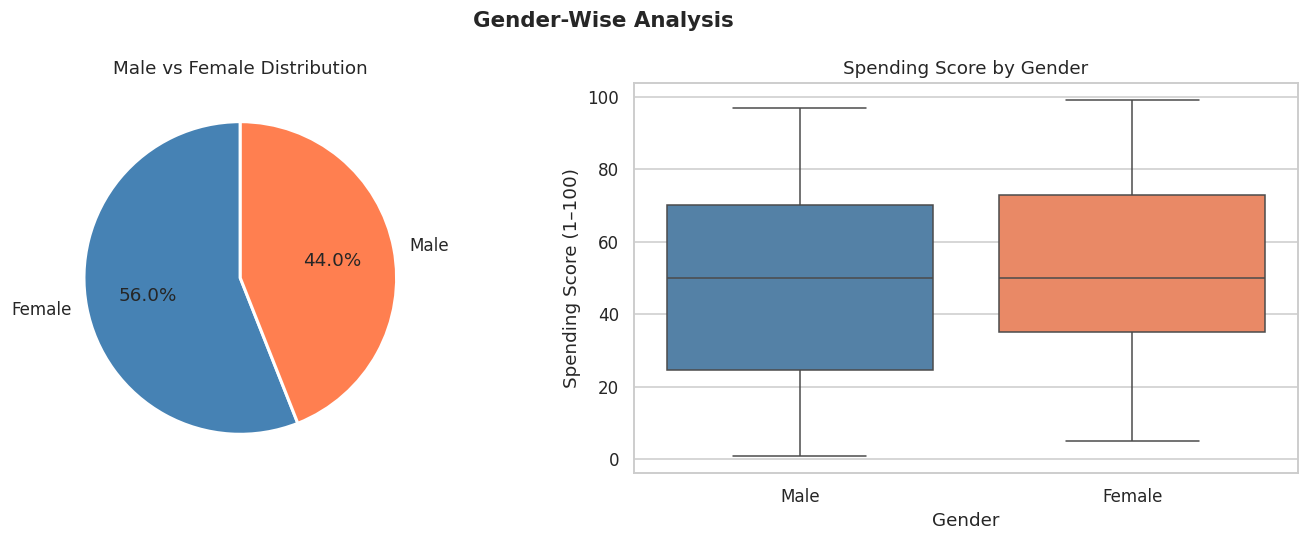

📌 56% of mall customers are Female. Female customers have slightly higher spending scores.


In [27]:


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gender-Wise Analysis', fontsize=14, fontweight='bold')

# Pie chart – proportion of Male vs Female
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Male vs Female Distribution')

# Box plot – spending score by gender
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)',
            palette={'Male': 'steelblue', 'Female': 'coral'}, ax=axes[1])
axes[1].set_title('Spending Score by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Spending Score (1–100)')

plt.tight_layout()
plt.savefig('eda_gender.png', bbox_inches='tight')
plt.show()
print("📌 56% of mall customers are Female. Female customers have slightly higher spending scores.")

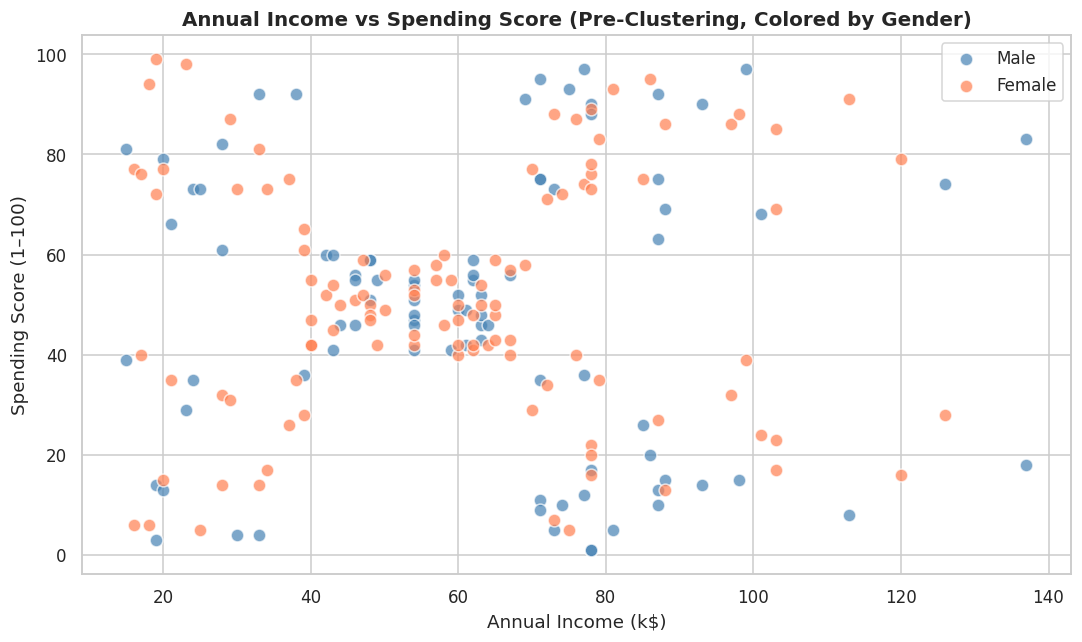

📌 Even without clustering, you can visually see ~5 natural groups in this scatter plot.
   This confirms that K-Means with K=5 is the right choice.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
#  EDA 4: Annual Income vs Spending Score (Pre-Clustering View)
# ─────────────────────────────────────────────────────────────────────────────

# This plot shows all customers before clustering, colored by Gender
plt.figure(figsize=(10, 6))

for gender, color in [('Male', 'steelblue'), ('Female', 'coral')]:
    subset = df[df['Gender'] == gender]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                label=gender, color=color, alpha=0.7, edgecolors='white', s=70)

plt.title('Annual Income vs Spending Score (Pre-Clustering, Colored by Gender)',
          fontsize=13, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('eda_income_vs_spending.png', bbox_inches='tight')
plt.show()
print("📌 Even without clustering, you can visually see ~5 natural groups in this scatter plot.")
print("   This confirms that K-Means with K=5 is the right choice.")

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
#  BUSINESS INSIGHTS – Marketing Strategy for Each Cluster
# ─────────────────────────────────────────────────────────────────────────────

business_strategies = {
    '🟢 Cluster 3 – Premium / VIP (High Income, High Spending)': [
        'Offer exclusive loyalty cards and VIP membership programs.',
        'Promote luxury brands, high-end products, and early access to new collections.',
        'Send personalized invitations for private sale events.',
        '→ Priority: RETENTION — They drive maximum revenue per visit.'
    ],
    '🔵 Cluster 1 – Conservative (High Income, Low Spending)': [
        'Focus messaging on quality, warranty, and value-for-money.',
        'Provide detailed product comparisons and expert reviews.',
        'Use limited-time offers to create urgency and trigger purchases.',
        '→ Priority: CONVERSION — They have money but need convincing.'
    ],
    '🟣 Cluster 4 – Impulsive Spenders (Low Income, High Spending)': [
        'Use social media campaigns, influencer promotions, and trending content.',
        'Offer Buy-Now-Pay-Later (BNPL) and easy EMI options.',
        'Promote fashion, gadgets, and peer-influenced trendy products.',
        '→ Priority: ENGAGEMENT — Keep them excited and visiting frequently.'
    ],
    '🔴 Cluster 2 – Budget Customers (Low Income, Low Spending)': [
        'Focus on discounts, bundle offers, and seasonal flash sales.',
        'Introduce a points/cashback loyalty program to encourage repeat visits.',
        'Promote affordable, value-for-money product ranges.',
        '→ Priority: VOLUME — Drive footfall through attractive pricing.'
    ],
    '🟠 Cluster 0 – Moderate / Average Customers': [
        'Reliable and stable — focus on retention and satisfaction.',
        'Use cross-selling ("Customers also bought...") and upselling strategies.',
        'Offer seasonal promotions and mid-range product recommendations.',
        '→ Priority: UPSELL — Nudge them toward higher-value purchases.'
    ]
}

print("═" * 68)
print("       BUSINESS INSIGHTS AND MARKETING RECOMMENDATIONS")
print("═" * 68)
for segment, tips in business_strategies.items():
    print(f"\n{segment}")
    for tip in tips:
        print(f"   • {tip}")

print("\n" + "═" * 68)
print("OVERALL STRATEGY SUMMARY")
print("═" * 68)
print("  1. Maximize revenue from Cluster 3 (VIP) — highest ROI.")
print("  2. Convert Cluster 1 (rich + cautious) with trust campaigns.")
print("  3. Engage Cluster 4 (young spenders) via digital platforms.")
print("  4. Drive volume from Cluster 2 (budget) via deals and discounts.")
print("  5. Upsell Cluster 0 (moderate) with personalized recommendations.")

════════════════════════════════════════════════════════════════════
       BUSINESS INSIGHTS AND MARKETING RECOMMENDATIONS
════════════════════════════════════════════════════════════════════

🟢 Cluster 3 – Premium / VIP (High Income, High Spending)
   • Offer exclusive loyalty cards and VIP membership programs.
   • Promote luxury brands, high-end products, and early access to new collections.
   • Send personalized invitations for private sale events.
   • → Priority: RETENTION — They drive maximum revenue per visit.

🔵 Cluster 1 – Conservative (High Income, Low Spending)
   • Focus messaging on quality, warranty, and value-for-money.
   • Provide detailed product comparisons and expert reviews.
   • Use limited-time offers to create urgency and trigger purchases.
   • → Priority: CONVERSION — They have money but need convincing.

🟣 Cluster 4 – Impulsive Spenders (Low Income, High Spending)
   • Use social media campaigns, influencer promotions, and trending content.
   • Offer Buy-

---
## 📏 Model Evaluation – Silhouette Score



| Score Range | Meaning |
|---|---|
| 0.71 – 1.00 | Excellent clustering |
| 0.51 – 0.70 | Good clustering |
| 0.26 – 0.50 | Fair clustering |
| ≤ 0.25 | Poor clustering |

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
#  MODEL EVALUATION: Silhouette Score for K=5
# ─────────────────────────────────────────────────────────────────────────────

# Calculate silhouette score — measures how well-separated the clusters are
sil_score = silhouette_score(X, cluster_labels)

print(f"Silhouette Score (K=5): {sil_score:.4f}")
print()

if sil_score >= 0.71:
    print("Interpretation: ⭐⭐⭐ EXCELLENT — clusters are very well separated.")
elif sil_score >= 0.51:
    print("Interpretation: ⭐⭐ GOOD — clusters are reasonably well separated.")
elif sil_score >= 0.26:
    print("Interpretation: ⭐ FAIR — some overlap between clusters exists.")
else:
    print("Interpretation: ⚠ POOR — significant cluster overlap. Try a different K.")

Silhouette Score (K=5): 0.5539

Interpretation: ⭐⭐ GOOD — clusters are reasonably well separated.


  K= 2  →  Silhouette Score = 0.2969
  K= 3  →  Silhouette Score = 0.4676
  K= 4  →  Silhouette Score = 0.4932
  K= 5  →  Silhouette Score = 0.5539
  K= 6  →  Silhouette Score = 0.5398
  K= 7  →  Silhouette Score = 0.5288
  K= 8  →  Silhouette Score = 0.4548
  K= 9  →  Silhouette Score = 0.4561
  K=10  →  Silhouette Score = 0.4411


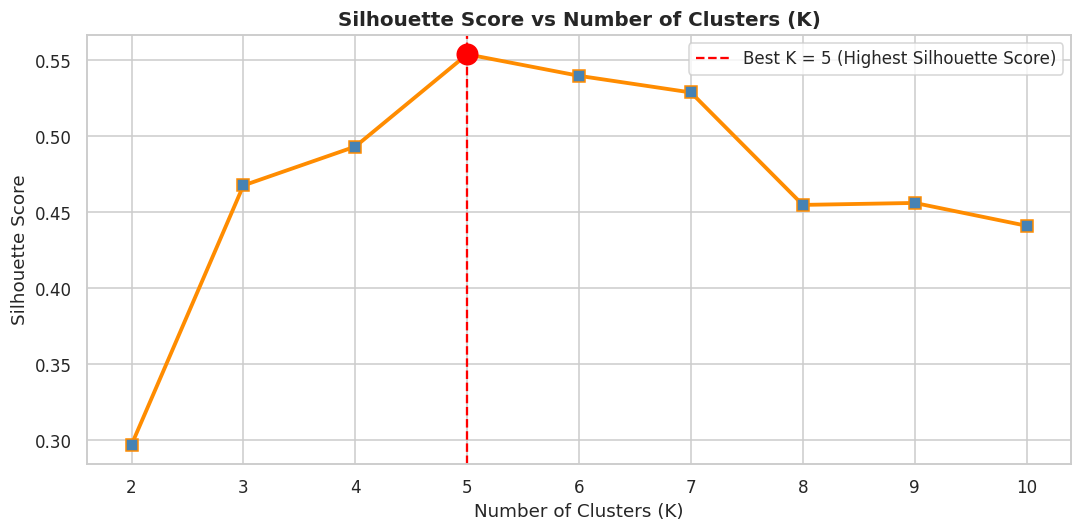


📌 Best silhouette score = 0.5539 at K=5
   This confirms our Elbow Method result — K=5 gives the best clustering quality.


In [31]:

#  Compare Silhouette Scores across K = 2 to 10
#  (Confirms K=5 is the best choice)


sil_scores = []
k_values = range(2, 11)      # Silhouette needs at least 2 clusters

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    lbs = km.fit_predict(X)
    score = silhouette_score(X, lbs)
    sil_scores.append(score)
    print(f"  K={k:2d}  →  Silhouette Score = {score:.4f}")

best_k = list(k_values)[sil_scores.index(max(sil_scores))]

# Plot silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(k_values, sil_scores, marker='s', color='darkorange',
         linewidth=2.5, markersize=8, markerfacecolor='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best K = {best_k} (Highest Silhouette Score)')
plt.scatter(best_k, max(sil_scores), s=180, color='red', zorder=5)
plt.title('Silhouette Score vs Number of Clusters (K)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(k_values))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('silhouette_plot.png', bbox_inches='tight')
plt.show()

print(f"\n📌 Best silhouette score = {max(sil_scores):.4f} at K={best_k}")
print("   This confirms our Elbow Method result — K=5 gives the best clustering quality.")

---
##  Conclusion

** – Conclusion:**  
Customer segmentation helps businesses identify valuable customers, improve marketing strategies, and make data-driven decisions. Clustering techniques like K-Means provide efficient and scalable solutions.

---

In this mini project, we successfully applied the **K-Means Clustering Algorithm** to segment 200 mall customers into **5 meaningful groups**:

| Cluster | Type | Action |
|---------|------|--------|
| Cluster 0 | Moderate Customers | Upsell via personalized offers |
| Cluster 1 | High Income, Low Spending | Convert with quality messaging |
| Cluster 2 | Low Income, Low Spending | Drive volume with discounts |
| Cluster 3 | High Income, High Spending 🏆 | Retain with VIP programs |
| Cluster 4 | Low Income, High Spending | Engage via social media & BNPL |

**Tools used:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn  
**Algorithm:** K-Means Clustering (k-means++ initialization)  
**Optimal K:** 5 (determined by Elbow Method + confirmed by Silhouette Score)  

This project demonstrates how **unsupervised machine learning** can turn raw customer data into actionable business intelligence — helping companies make smarter, data-driven decisions.

---
*End of Mini Project – Customer Segmentation using K-Means Clustering Algorithm*  
*Submitted in partial fulfillment of VTU Mini Project Requirements*
